In [1]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import TextVectorization
from sklearn.metrics import f1_score
from torch.utils.data import Dataset, DataLoader
from torch.nn import BCELoss, Module, Linear, Dropout, Sigmoid, GRU, Embedding
from torch.optim import Adam
import torch
from wordcloud import WordCloud, STOPWORDS
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import re

mpl.rcParams['figure.dpi'] = 150

In [ ]:
path = kagglehub.dataset_download("saurabhshahane/fake-news-classification")
data_path = os.listdir(path)[0]
full_path = os.path.join(path, data_path)
print(f"Full Path: {full_path}")

In [17]:
df = pd.read_csv(full_path)
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [18]:
df.shape

(72134, 4)

In [19]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [20]:
df.isnull().mean()

title    0.007736
text     0.000541
label    0.000000
dtype: float64

In [21]:
df.dropna(inplace=True)

In [22]:
print("Number of duplicated rows: ", df.duplicated().sum())

Number of duplicated rows:  8416


In [23]:
df.drop_duplicates(inplace=True)

In [24]:
print('Label value counts: \n', df['label'].value_counts())

Label value counts: 
 label
0    34791
1    28330
Name: count, dtype: int64


In [25]:
df['news'] = df['title'] + ' ' + df['text']
df['news']

0        LAW ENFORCEMENT ON HIGH ALERT Following Threat...
2        UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3        Bobby Jindal, raised Hindu, uses story of Chri...
4        SATAN 2: Russia unvelis an image of its terrif...
5        About Time! Christian Group Sues Amazon and SP...
                               ...                        
72127    WIKILEAKS EMAIL SHOWS CLINTON FOUNDATION FUNDS...
72129    Russians steal research on Trump in hack of U....
72130     WATCH: Giuliani Demands That Democrats Apolog...
72131    Migrants Refuse To Leave Train At Refugee Camp...
72132    Trump tussle gives unpopular Mexican leader mu...
Name: news, Length: 63121, dtype: object

In [26]:
stemmer = SnowballStemmer(language='english')

def text_preprocessing(text):
    text_lowers = text.lower()
    text_cleaned = re.sub(r"[^a-z]+", " ", text_lowers)
    tokens = word_tokenize(text_cleaned)
    tokens_stem = [stemmer.stem(tok) for tok in tokens if len(tok) > 1]
    return ' '.join(tokens_stem)

df['news_cleaned'] = df['news'].apply(text_preprocessing)
df.head()

,title,text,label,news,news_cleaned
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforc on high alert follow threat against...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbeliev obama attorney general say most charl...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri...",bobbi jindal rais hindu use stori of christian...
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...,satan russia unv an imag of it terrifi new sup...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,About Time! Christian Group Sues Amazon and SP...,about time christian group sue amazon and splc...


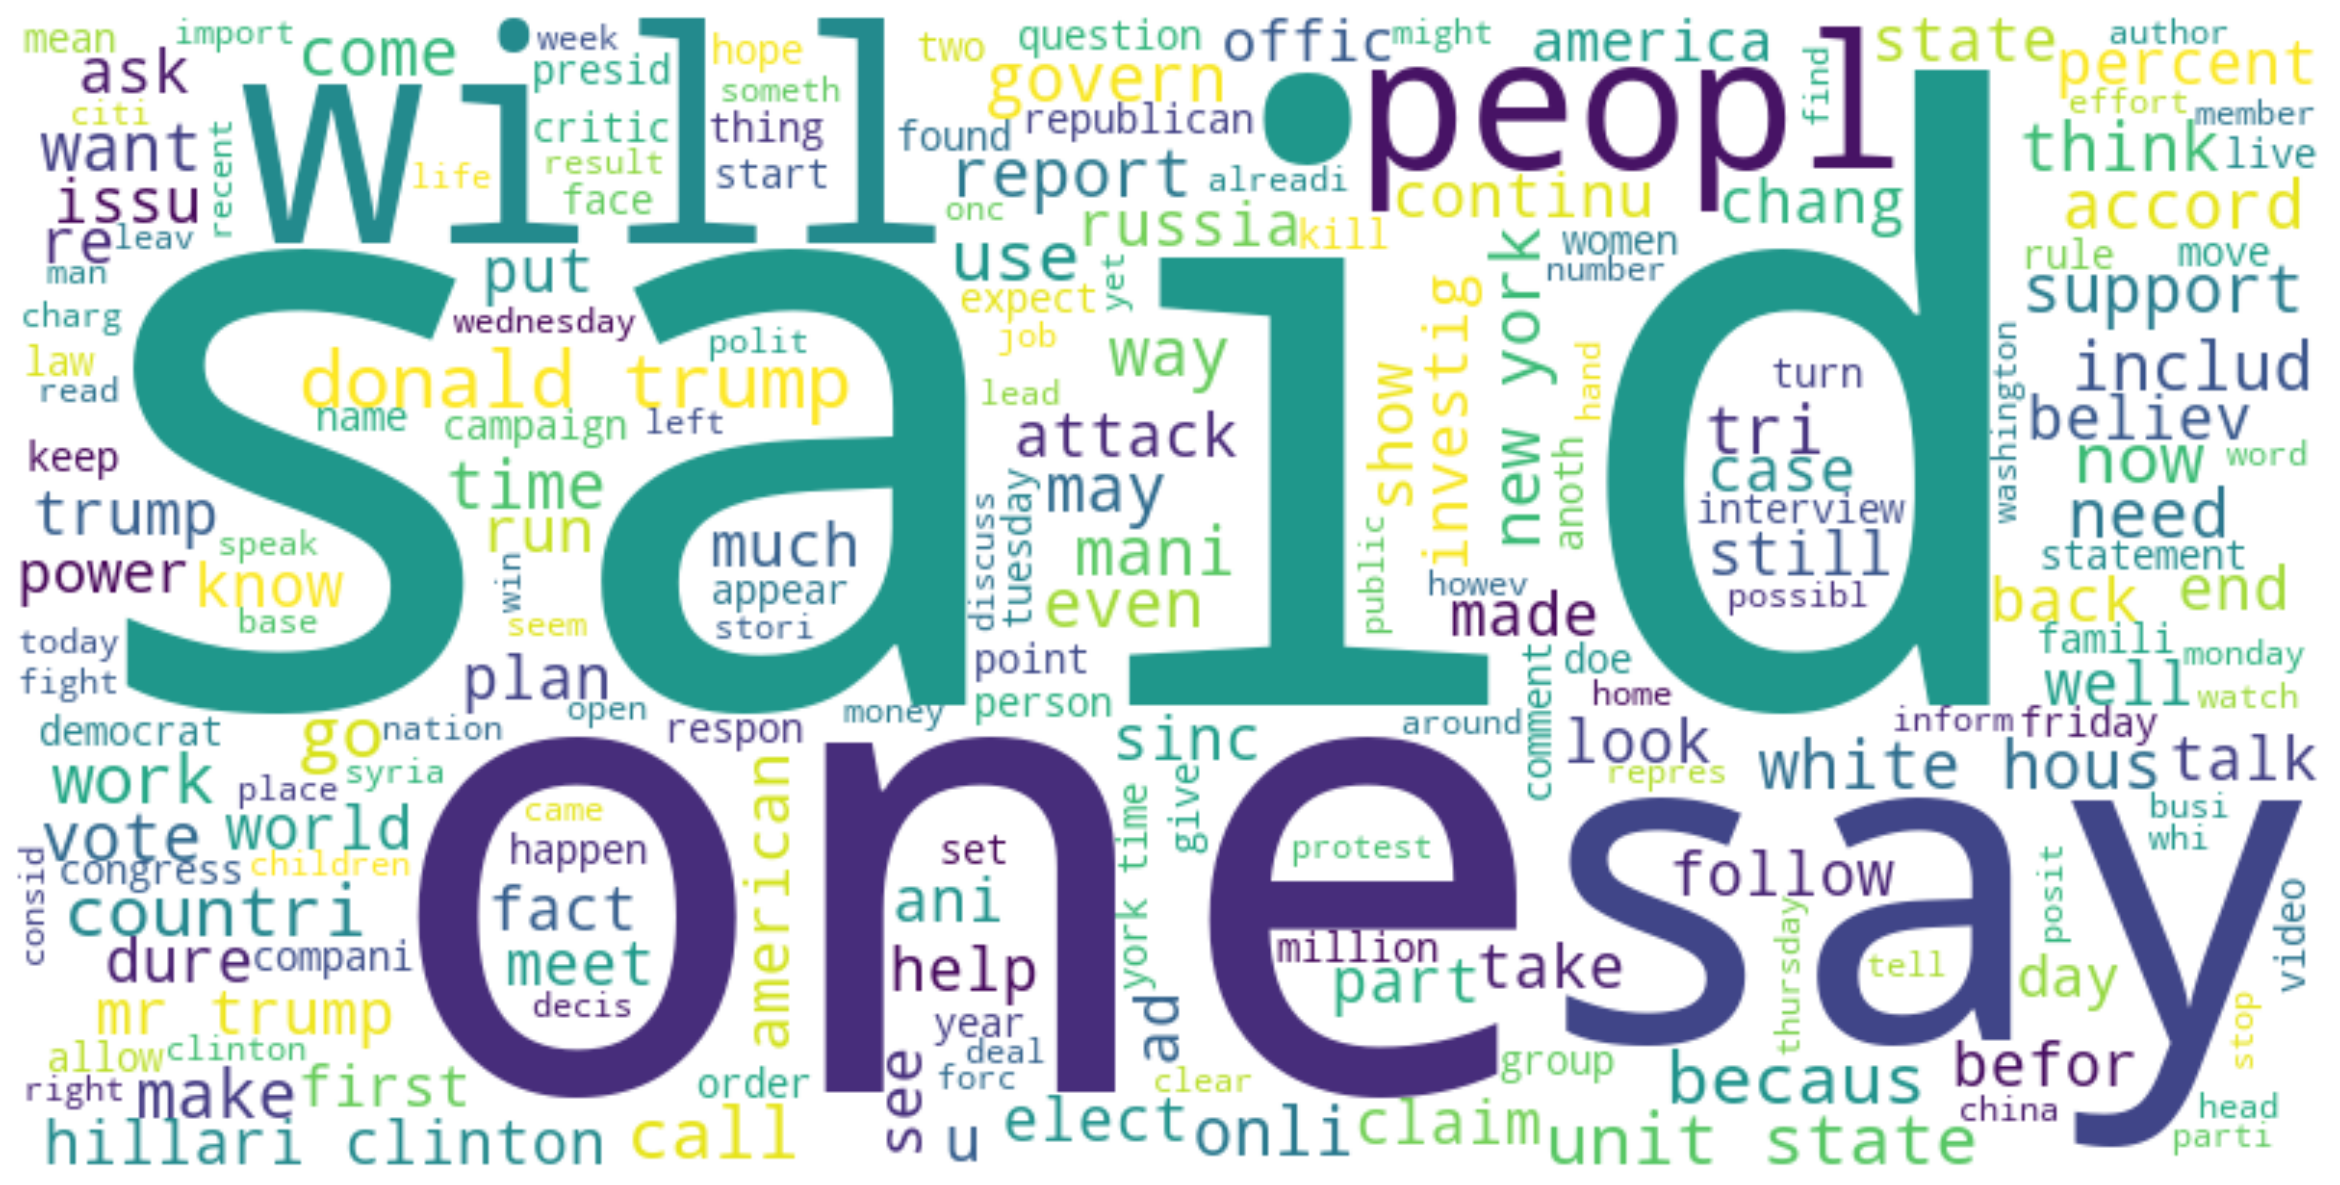

In [27]:
full_text = ' '.join(df['news_cleaned'])

cloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    stopwords=STOPWORDS
).generate(full_text)

plt.figure(figsize=(20, 10))
plt.imshow(cloud, interpolation='bilinear')
plt.axis("off")
plt.show()

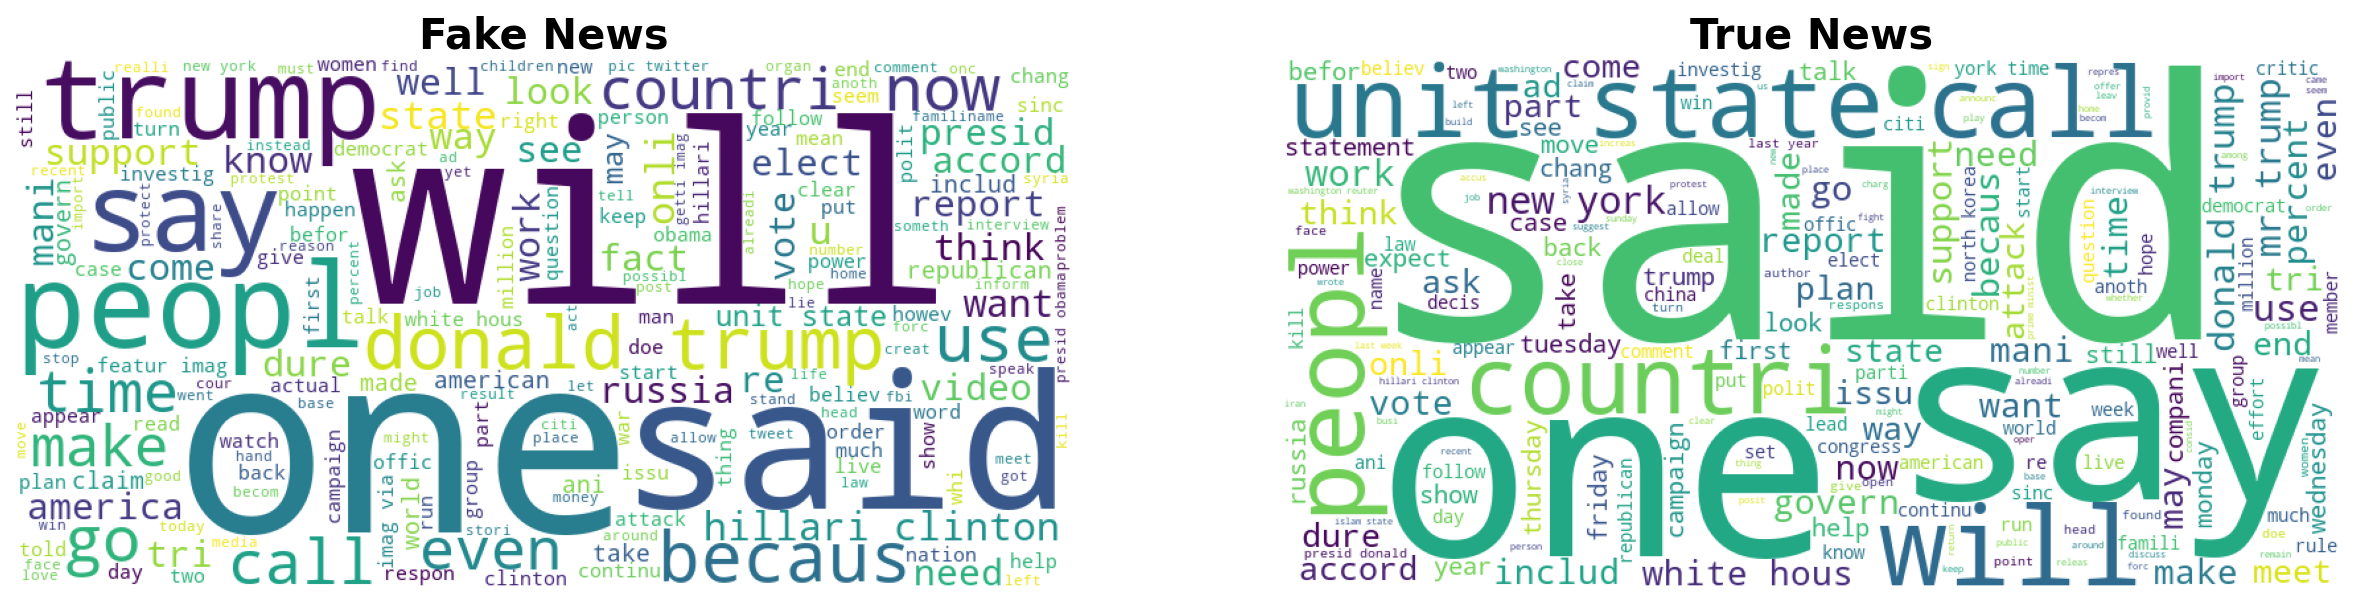

In [28]:
fake_news_full_text = ' '.join(df[df['label'] == 1]['news_cleaned'])
true_news_full_text = ' '.join(df[df['label'] == 0]['news_cleaned'])

def make_cloud(text):
    return WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis',
        stopwords=STOPWORDS
    ).generate(text)
    

fig, axs = plt.subplots(1, 2, figsize=(20, 10)) 

axs[0].imshow(make_cloud(fake_news_full_text))
axs[0].set_title("Fake News", fontsize=20, fontweight="bold")

axs[1].imshow(make_cloud(true_news_full_text))
axs[1].set_title("True News", fontsize=20, fontweight="bold")

for ax in axs:
    ax.axis('off')
plt.show()

In [29]:
X = df['news_cleaned']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(X_train.shape, X_val.shape, X_test.shape)

(45446,) (11362,) (6313,)


In [58]:
vectorizer = TextVectorization(
    max_tokens=20000,
    standardize=None,
    ngrams=(1, 2),
    output_mode='int',
    output_sequence_length=512
)

vectorizer.adapt(X_train)

X_train_vec = vectorizer(X_train)
X_val_vec = vectorizer(X_val)
X_test_vec = vectorizer(X_test)

vocab = vectorizer.get_vocabulary()
vocab_size = len(vocab)

with open("vocab.txt", "w", encoding="utf-8") as f:
    for token in vocab:
        f.write(token + "\n")

In [59]:
class FakeNewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.numpy(), dtype=torch.long)
        self.y = y
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y.iloc[idx]
    
train_dataset = FakeNewsDataset(X_train_vec, y_train)
val_dataset = FakeNewsDataset(X_val_vec, y_val)
test_dataset = FakeNewsDataset(X_test_vec, y_test)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [60]:
class FakeNewsModel(Module):
    def __init__(self, embed_input, embed_dim, dropout_rate, hidden_size, layers_number):
        super(FakeNewsModel, self).__init__()
        
        self.embed = Embedding(num_embeddings=embed_input, embedding_dim=embed_dim)
        self.dropout = Dropout(p=dropout_rate)
        self.gru = GRU(input_size=embed_dim, hidden_size=hidden_size, num_layers=layers_number, batch_first=True)
        self.fc = Linear(in_features=hidden_size, out_features=1)
        self.sigmoid = Sigmoid()
        
    def forward(self, X):
        x = self.embed(X)
        x = self.dropout(x)
        output, h = self.gru(x)
        x = self.fc(h[-1])
        x = self.sigmoid(x)
        return x

In [62]:
torch.random.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = FakeNewsModel(
    embed_input=vocab_size,
    embed_dim=100,
    dropout_rate=0.2,
    hidden_size=128,
    layers_number=2
).to(device)

criterion = BCELoss()
optimizer = Adam(model.parameters(), lr=0.001)

def train_epoch(dataset, model, crit, optim, device):
    model_loss = 0.0
    true_labels = []
    predicts = []
    
    model.train()
    for X, y in dataset:
        X, y = X.to(device), y.to(device).float()
        
        output = model(X)
        loss = crit(output.squeeze(1), y)
        model_loss += loss.item()
        
        pred_labels = (output >= 0.5).cpu().numpy().tolist()
        true_labels.extend(y.cpu().numpy().tolist())
        predicts.extend(pred_labels)
        
        loss.backward()
        optim.step()
        optim.zero_grad()
    
    loss = model_loss / len(dataset)
    f1_macro = f1_score(true_labels, predicts, average='macro')
    
    return loss, f1_macro

def val_epoch(dataset, model, crit, device):
    model_loss = 0.0
    true_labels = []
    predicts = []
    
    model.eval()
    for X, y in dataset:
        X, y = X.to(device), y.to(device).float()
        
        with torch.no_grad():
            output = model(X)
            loss = crit(output.squeeze(1), y)
            
        model_loss += loss.item()
        
        pred_labels = (output >= 0.5).cpu().numpy().tolist()
        true_labels.extend(y.cpu().numpy().tolist())
        predicts.extend(pred_labels)
    
    loss = model_loss / len(dataset)
    f1_macro = f1_score(true_labels, predicts, average='macro')
    
    return loss, f1_macro


EPOCHS = 10

min_loss = float('inf')
for epoch in range(EPOCHS):
    train_loss, train_f1_macro = train_epoch(
        dataset=train_loader, model=model, 
        crit=criterion, optim=optimizer, device=device
    )
    val_loss, val_f1_macro = val_epoch(
        dataset=val_loader, model=model, 
        crit=criterion, device=device
    )
    
    print(f'Epoch: {epoch+1}/{EPOCHS}... --> Train Loss: {train_loss:.6f},'
          f' Train F1 macro: {train_f1_macro:.6f} | Val Loss: {val_loss:.6f}, Val F1 macro: {val_f1_macro:.6f}')
    
    if val_loss < min_loss:
        min_loss = val_loss
        torch.save({'model_state_dict': model.state_dict()}, 'model_weights.pt')

Epoch: 1/10... --> Train Loss: 0.430489, Train F1 macro: 0.752877 | Val Loss: 0.154047, Val F1 macro: 0.940464
Epoch: 2/10... --> Train Loss: 0.117560, Train F1 macro: 0.953291 | Val Loss: 0.100721, Val F1 macro: 0.959185
Epoch: 3/10... --> Train Loss: 0.080779, Train F1 macro: 0.968839 | Val Loss: 0.089313, Val F1 macro: 0.966350
Epoch: 4/10... --> Train Loss: 0.060512, Train F1 macro: 0.977243 | Val Loss: 0.098771, Val F1 macro: 0.964481
Epoch: 5/10... --> Train Loss: 0.043951, Train F1 macro: 0.983929 | Val Loss: 0.096678, Val F1 macro: 0.968502
Epoch: 6/10... --> Train Loss: 0.033405, Train F1 macro: 0.987529 | Val Loss: 0.091490, Val F1 macro: 0.970155
Epoch: 7/10... --> Train Loss: 0.025247, Train F1 macro: 0.990862 | Val Loss: 0.090344, Val F1 macro: 0.971890
Epoch: 8/10... --> Train Loss: 0.020332, Train F1 macro: 0.992551 | Val Loss: 0.100398, Val F1 macro: 0.969091
Epoch: 9/10... --> Train Loss: 0.016363, Train F1 macro: 0.993996 | Val Loss: 0.100080, Val F1 macro: 0.969595
E

In [64]:
def test(dataset, model, crit, device):
    model_loss = 0.0
    true_labels = []
    predicts = []
    
    model.eval()
    for X, y in dataset:
        X, y = X.to(device), y.to(device).float()
        
        with torch.no_grad():
            output = model(X)
            loss = crit(output.squeeze(1), y)
            
        model_loss += loss.item()
        
        pred_labels = (output >= 0.5).cpu().numpy().tolist()
        true_labels.extend(y.cpu().numpy().tolist())
        predicts.extend(pred_labels)
    
    loss = model_loss / len(dataset)
    f1_macro = f1_score(true_labels, predicts, average='macro')
    
    return loss, f1_macro

test_loss, test_f1_macro = test(test_loader, model, criterion, device)
print(f'Test Loss: {test_loss:.6f}, Test F1 macro: {test_f1_macro:.6f}')

Test Loss: 0.131459, Test F1 macro: 0.970222
